In [1]:
import numpy as np
import helmeos as helmeos
import matplotlib.pyplot as plt

In [2]:
gconst = 6.67430e-8
clight = 2.99792458e10
solar = 1.98847e33
lencgs2code = (clight**2)/(solar*gconst)
masscgs2code = (1.0e0/solar)
rhocgs2code = (masscgs2code/lencgs2code**3)
tcgs2code = (clight**3)/(solar*gconst)
mu_0 = 1.25663706212e-6
amp2code = (mu_0*1.0e5*masscgs2code*lencgs2code)**(0.5e0)/tcgs2code
gauss2code = 1.0e-1*masscgs2code/amp2code/tcgs2code**2
energycgs2code = (1.0E0/clight**2)
me2 = 9.1093837015e-28*masscgs2code
mb2 = 1.66053906660e-24*masscgs2code
ye = 0.5e0
h_bar = (1.054571817e-27)*(lencgs2code**2*masscgs2code/tcgs2code)
amax = (me2**4)/(2.4e1*np.pi**2*h_bar**3)
bmax = (mb2*me2**3)/(3.0e0*np.pi**2*h_bar**3*ye)

In [13]:
1/(rhocgs2code*energycgs2code)

5.550222147402627e+38

In [82]:
code_dens = np.loadtxt('/home/cnchong/Codes/cumc3d/model/Type_Ia/outfile/density.csv',delimiter=',')/(masscgs2code/lencgs2code**3)
code_eps = np.loadtxt('/home/cnchong/Codes/cumc3d/model/Type_Ia/outfile/epsilon.csv',delimiter=',')/energycgs2code
code_temp = np.loadtxt('/home/cnchong/Codes/cumc3d/model/Type_Ia/outfile/temp.csv',delimiter=',')*1e9
code_abar = np.loadtxt('/home/cnchong/Codes/cumc3d/model/Type_Ia/outfile/abar.csv',delimiter=',')
code_zbar = np.loadtxt('/home/cnchong/Codes/cumc3d/model/Type_Ia/outfile/zbar.csv',delimiter=',')
code_pressure = np.loadtxt('/home/cnchong/Codes/cumc3d/model/Type_Ia/outfile/pressure.csv',delimiter=',')/(masscgs2code*energycgs2code/lencgs2code**3)

In [83]:
code_eps

array([[9.73399523e+15, 9.73399523e+15, 9.73399523e+15, ...,
        9.73399523e+15, 9.73399523e+15, 9.73399523e+15],
       [9.73399523e+15, 9.73399523e+15, 9.73399523e+15, ...,
        9.73399523e+15, 9.73399523e+15, 9.73399523e+15],
       [9.73399523e+15, 9.73399523e+15, 9.73399523e+15, ...,
        9.73399523e+15, 9.73399523e+15, 9.73399523e+15],
       ...,
       [9.73399523e+15, 9.73399523e+15, 9.73399523e+15, ...,
        9.73399523e+15, 9.73399523e+15, 9.73399523e+15],
       [9.73399523e+15, 9.73399523e+15, 9.73399523e+15, ...,
        9.73399523e+15, 9.73399523e+15, 9.73399523e+15],
       [9.73399523e+15, 9.73399523e+15, 9.73399523e+15, ...,
        9.73399523e+15, 9.73399523e+15, 9.73399523e+15]])

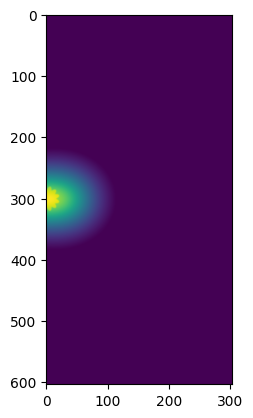

In [84]:
out = helmeos.eos_DT(code_dens, code_temp, code_abar, code_zbar)
plt.imshow(out['etot'])

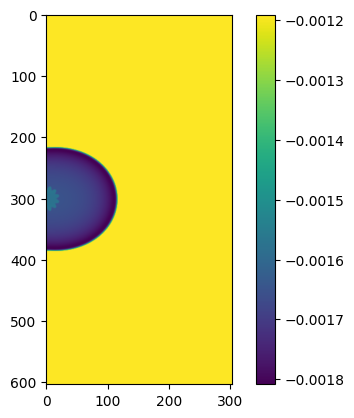

In [87]:
plt.imshow((code_eps-out['etot'])/out['etot'])
plt.colorbar()

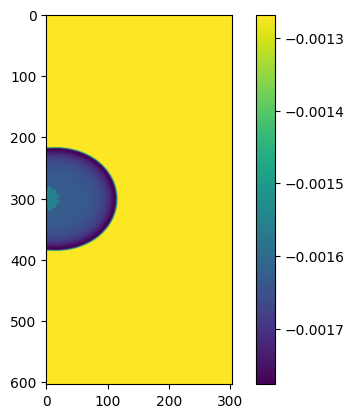

In [88]:
plt.imshow((code_pressure-out['ptot'])/out['ptot'])
plt.colorbar()

In [31]:
inv = helmeos.eos_invert(299.83501317337806, abar, zbar, 8.34e-6/energycgs2code, 'etot')
inv

array(85464716.08937639)